# Get Initial LPS from the STCAV image and save it as BELT input format 



In [5]:
import numpy as np
import os

import h5py

from skimage.filters import sobel
from skimage.util import img_as_ubyte
from skimage.segmentation import watershed
from skimage.filters.rank import median
from skimage.morphology import disk
from pmd_beamphysics.units import mec2, c_light
import scipy.ndimage as ndimage

import matplotlib.pyplot as plt
import epics
import scipy

In [6]:
# Nicer plotting
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

In [7]:
data_filename = 'STCAV_data/ProfMon-OTRS_DIAG0_525-2025-04-05-120053.mat'
#data_filename = 'STCAV_data/ProfMon-OTRS_DIAG0_525-2025-05-17-101524.mat'
distgen_xy_dist_filename = 'STCAV_data/DIAG0_LPS_1mm_004052025.txt'
particle_h5_filename = 'STCAV_data/particle-2025-04-05_2.h5'

#scaling parameters
energy_res = 10090  # um / MeV   http://physics-elog.slac.stanford.edu/lcls2elog/show.jsp?dir=/2025/14/05.04&pos=2025-04-05T18:00:57
z_res  = 799*1.2#777#799 # um/degree

In [8]:
799*1.1

878.9000000000001

## Read matlab data

In [9]:
import scipy.io

In [10]:
f = h5py.File(data_filename, 'r')

In [11]:
res = np.array(f['data']['res'])[0][0]
print(res)

25.09


/lscratch/jytang/tmp/ipykernel_3974298/3233954316.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  res = np.array(f['data']['res'])[0][0]


In [12]:
print(f['data'].keys())

<KeysViewHDF5 ['back', 'bitdepth', 'centerX', 'centerY', 'filtOD', 'filtStat', 'img', 'imgAttn', 'isRaw', 'nCol', 'nRow', 'name', 'orientX', 'orientY', 'pulseId', 'res', 'roiX', 'roiXN', 'roiY', 'roiYN', 'ts']>


In [13]:
img = np.array(f['data']['img'])

/lscratch/jytang/tmp/ipykernel_3974298/1105185536.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  img = np.array(f['data']['img'])


In [14]:
f.close()

# Image tools

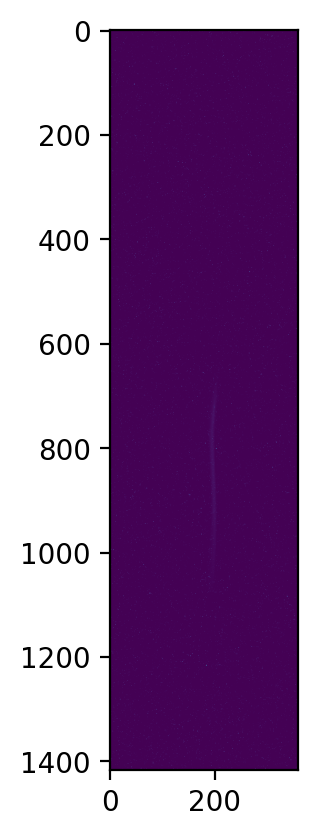

In [15]:
plt.imshow(img)

In [16]:
fclip = 0.00
img[img < np.max(img)* fclip] = 0

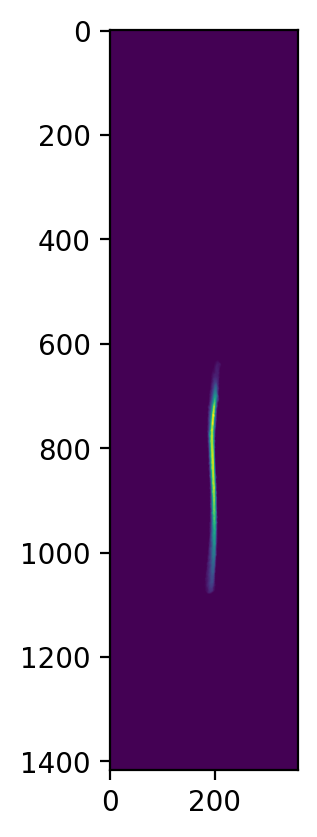

In [17]:
img3 = scipy.ndimage.median_filter(img, size = (5,5))
img3 = img3
plt.imshow(img3)

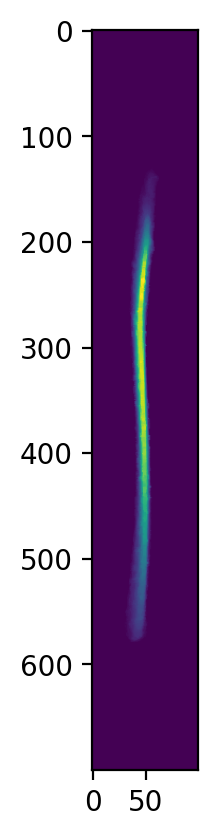

In [18]:
#cutimg = img3[500:1100, 900:1100]
cutimg = img3[500:1200, 150:250]

plt.imshow(cutimg)
#plt.xlim([0, 200])

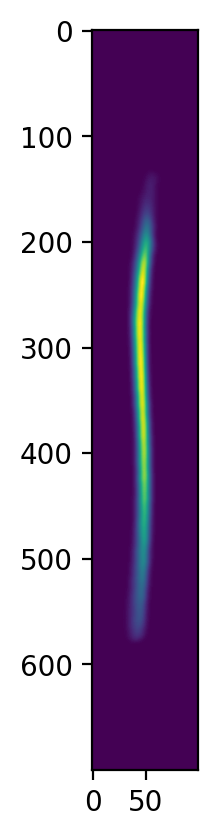

In [19]:
cutimg_smooth = ndimage.gaussian_filter(cutimg, sigma=(3, 3), order=0)
#cutimg_smooth = cutimg
plt.imshow(cutimg_smooth)

In [20]:
def write_distgen_xy_dist(filename, image, resolution, resolution_units='um'):
    """
    Writes image data in distgen's xy_dist format
    
    Returns the absolute path to the file written
    
    """
    
    # Get width of each dimension
    widths = resolution * np.array(image.shape)
    
    center_y = 0
    center_x = 0
    
    # Form header
    header = f"""x {widths[1]} {center_x} [{resolution_units}]
y {widths[0]} {center_y}  [{resolution_units}]"""
    
    # Save with the correct orientation
    np.savetxt(filename, np.flip(image, axis=0), header=header, comments='')
    
    return os.path.abspath(filename)

In [21]:
fout = write_distgen_xy_dist(distgen_xy_dist_filename, cutimg_smooth.T,
                                 res,
                                 resolution_units='um')
    

    
# import matplotlib.pyplot as plt
# %config InlineBackend.figure_format = 'retina'
# fout, i1, i2 = get_live_distgen_xy_dist(vcc_device='CAMR:LGUN:950', fclip=0.08)
# # #fout, i1, i2 = get_live_distgen_xy_dist(vcc_device='CAMR:LT10:900', fclip=0.08)
# # 
# plt.imshow(i2)
# fout
# # 

## Run Distgen

In [22]:
from distgen import Generator

units = {
    "x": "mm",
    "y": "mm",
    "r": "mm",
    "z": "mm",
    "px": "keV/c",
    "py": "keV/c",
    "pz": "MeV/c",
    "t": "ps",
    "q": "pC",
    "thetax": "mrad",
    "thetay": "mrad",
}

In [23]:
gen = Generator("STCAV_data/distgen.yaml", verbose=0)
gen["xy_dist:file"] = distgen_xy_dist_filename
initial_beam = gen.beam()

#R = 1.0  # mm
#Theta = 45  # deg

#set_x = {"type": "set_avg x", "avg_x": {"value": R, "units": "mm"}}
#rotxy = {"type": "rotate2d x:y", "angle": {"value": Theta, "units": "deg"}}

#gen["transforms"] = {"r": set_x, "theta": rotxy}
#gen["transforms"] = {"r": set_x}

#final_beam = gen.beam()

<Axes: xlabel='$t$ (ps)', ylabel='$p_z$ (MeV/c)'>

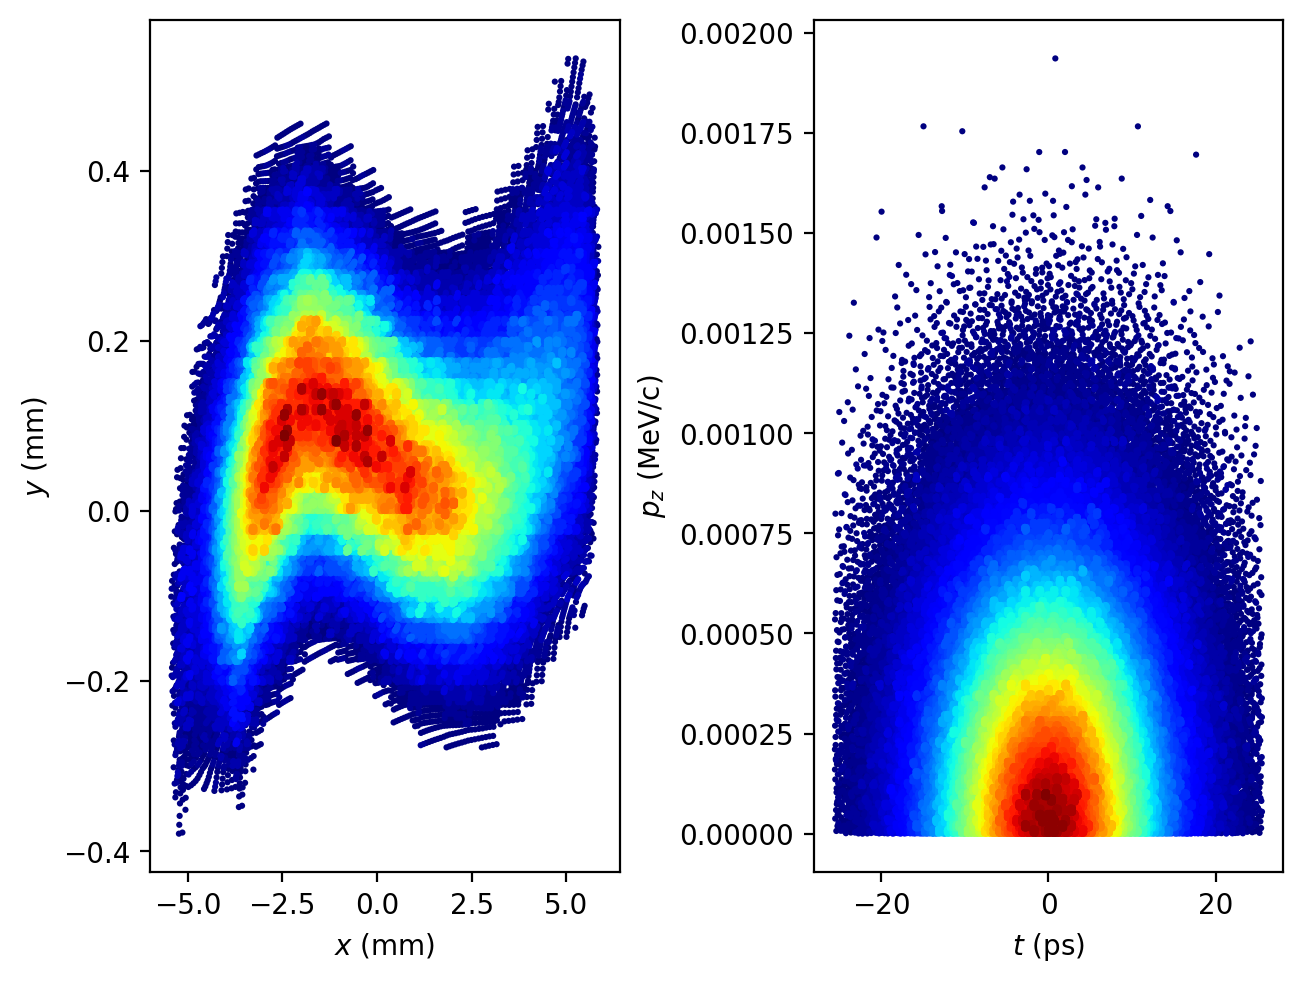

In [24]:
from distgen.plot import plot_dist2d
import matplotlib.pyplot as plt
from distgen.physical_constants import unit_registry as unit
fig, ax = plt.subplots(1, 2, sharex="col", constrained_layout=True)

plot_dist2d(initial_beam, "x", units["x"], "y", units["y"],  ax=ax[0])
plot_dist2d(initial_beam, "t", units["t"], "pz", units["pz"],  ax=ax[1])


In [25]:
gen.run()
pg = gen.particles

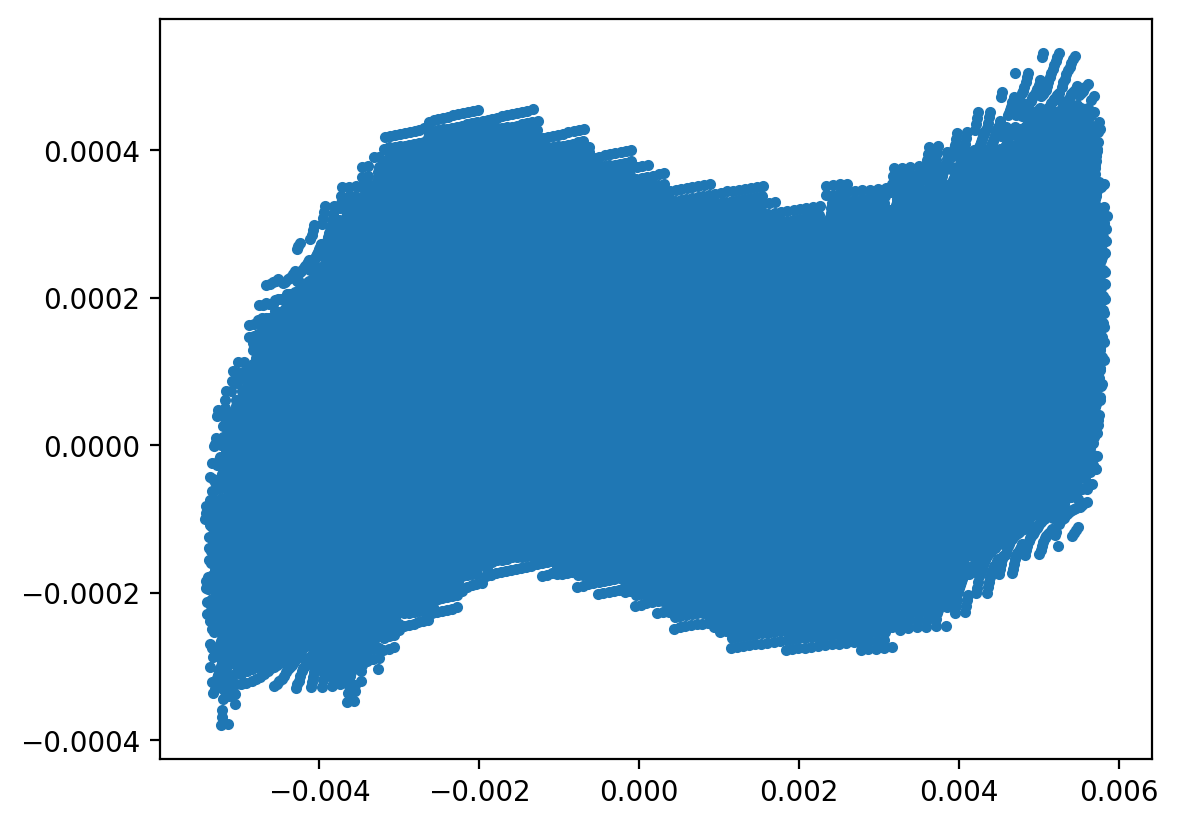

In [26]:
x = pg.x
y = pg.y
plt.plot(x, y, '.')

In [27]:
epics.PV('ACCL:L0B:0100:AACTMEANSUM').get()*1e6

TypeError: unsupported operand type(s) for *: 'NoneType' and 'float'

In [30]:

f =  2.856e9

mean_energy = 75e6
charge = 60e-12

#read charge from PV
#mean_energy = epics.PV('ACCL:L0B:0100:AACTMEANSUM').get()*1e6
#charge = epics.PV('BPMS:GUNB:314:TMIT').get()*1.6e-19



#bunch_length = 1.1e-3

T = 1/f


energy = y*1e12/energy_res #eV
energy -= np.mean(energy)
#energy/=1.5
energy += mean_energy
t = -x*1e6/z_res/360*T  #!Should there be a negative sign?
z = t*c_light

#z *= bunch_length/np.std(z)

print("rms energy spread", np.std(energy)/1e3, "keV")
print("rms bunch length", np.std(z)*1e3, "mm")

rms energy spread 11.77191650269486 keV
rms bunch length 0.781812934794281 mm


In [31]:
mean_energy

75000000.0

In [32]:
from pmd_beamphysics import ParticleGroup
gamma = energy/mec2
n = len(z)
weight = charge/n

pz = np.sqrt(gamma**2 - 1) * mec2
particlegroup_data = dict(
    t=t,
    x=np.zeros(n),
    px=np.zeros(n),
    y=np.zeros(n),
    py=np.zeros(n),
    z=z,
    pz=pz,
    weight=weight*np.ones(n),
    status=np.ones(n),
    species="electron",
    )
pg1 = ParticleGroup(data=particlegroup_data)

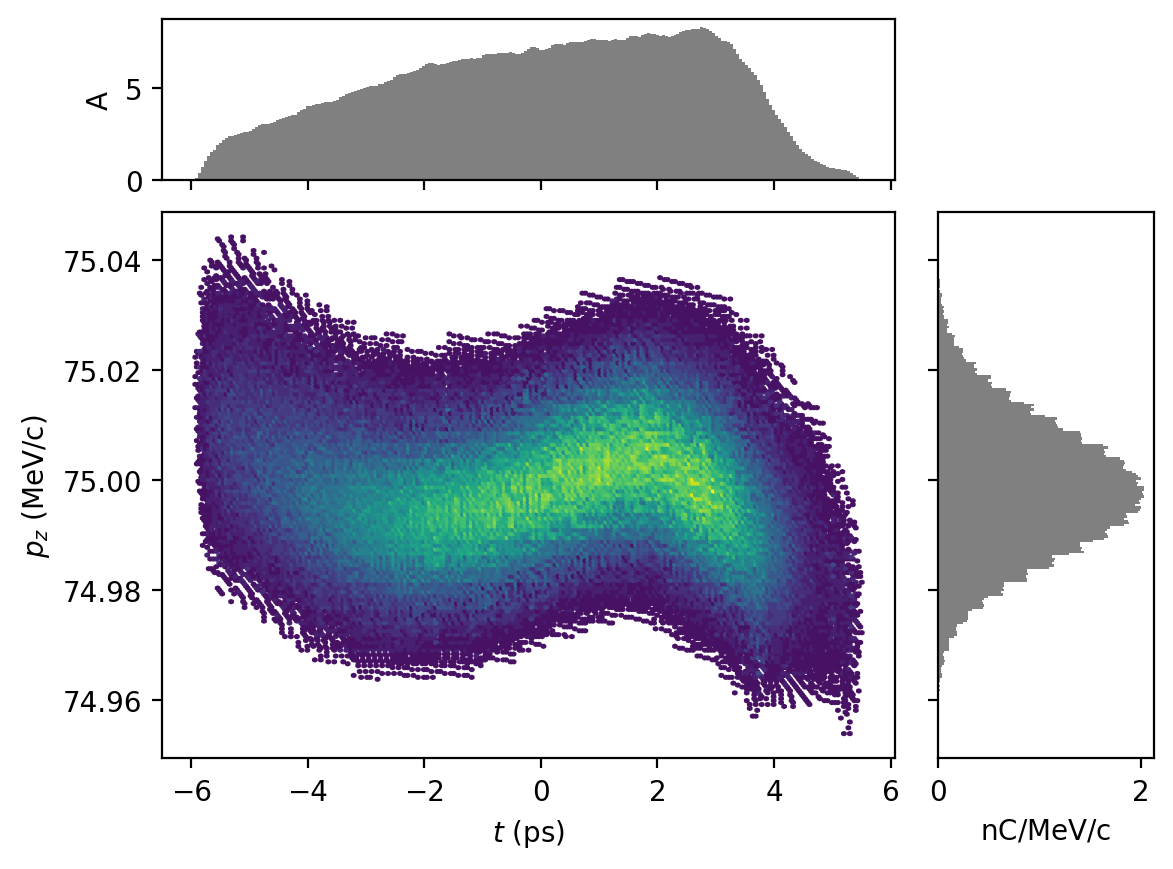

In [33]:
pg1.plot('t', 'pz')

In [34]:
pg1.charge

np.float64(6.000000000000001e-11)

In [35]:
pg1['sigma_energy']

np.float64(11771.91650269485)

In [36]:
pg1.write(particle_h5_filename)

In [167]:
777/1.1

706.3636363636363